# So sánh 4 mô hình

In [6]:
import os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def find_root(marker='Data/train.csv'):
    for d in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (d / marker).exists():
            return d
    raise FileNotFoundError('Không thấy repo root')
ROOT = find_root()

cfg = {'RL':    ROOT / 'Modeling' / 'Stats' / 'RL' / 'rl_per_kpi_config.json',
       'ARIMA': ROOT / 'Modeling' / 'Stats' / 'ARIMA' / 'arima_per_kpi_config.json',
       'STL':   ROOT / 'Modeling' / 'Stats' / 'STL' / 'stl_per_kpi_config.json',
       'IF':    ROOT / 'Modeling' / 'ML' / 'IsolationForest' / 'if_per_kpi_config.json'}
for name, pth in cfg.items():
    print(('CÓ   ' if os.path.exists(pth) else 'THIẾU'), name, '->', pth.name)

rl    = pd.read_json(cfg['RL'])
arima = pd.read_json(cfg['ARIMA'])
stl   = pd.read_json(cfg['STL'])
iff   = pd.read_json(cfg['IF'])
MODELS = ['RL', 'ARIMA', 'STL', 'IF']

CÓ    RL -> rl_per_kpi_config.json
CÓ    ARIMA -> arima_per_kpi_config.json
CÓ    STL -> stl_per_kpi_config.json
CÓ    IF -> if_per_kpi_config.json


## Chuẩn hoá 4 config về một khung chung

In [7]:
# ---- gộp 4 config về schema chung (PW-only; chọn model theo AP_val) ----
rl_s = pd.DataFrame({'kpi': rl.kpi, 'RL_AP': rl.ap_test, 'RL_APval': rl.ap_val,
                     'RL_ROC': rl.roc, 'RL_P': rl.prec, 'RL_R': rl.rec,
                     'RL_PWF1': rl.f1_pw, 'RL_TTD': rl.ttd_sec,
                     'RL_param': rl.window.map(lambda w: f'w={w}')})

ar_s = pd.DataFrame({'kpi': arima.kpi, 'ARIMA_AP': arima.AP, 'ARIMA_APval': arima.AP_val,
                     'ARIMA_ROC': arima.ROC, 'ARIMA_P': arima.PW_P, 'ARIMA_R': arima.PW_R,
                     'ARIMA_PWF1': arima.PW_F1, 'ARIMA_TTD': arima.ttd_s,
                     'ARIMA_param': arima.order.astype(str)})

st_s = pd.DataFrame({'kpi': stl.kpi, 'STL_AP': stl.AP, 'STL_APval': stl.AP_val,
                     'STL_ROC': stl.ROC, 'STL_P': stl.PW_P, 'STL_R': stl.PW_R,
                     'STL_PWF1': stl.PW_F1, 'STL_TTD': stl.ttd_s,
                     'STL_param': stl.period.map(lambda p: f'period={p}')})

route = np.where(iff.b_AP_val >= iff.a_AP_val, 'feat', 'shingle')
pick = lambda b, a: np.where(route == 'feat', b, a)
if_s = pd.DataFrame({'kpi': iff.kpi,
                     'IF_AP':    iff.b_AP,
                     'IF_APval': iff.b_AP_val,
                     'IF_ROC':   iff.b_ROC,
                     'IF_P':     iff.b_PW_P,
                     'IF_R':     iff.b_PW_R,
                     'IF_PWF1':  iff.b_PW_F1,
                     'IF_TTD':   np.nan,
                     'IF_param': iff.b_n_feat.map(lambda n: f'feat(n={n})')})

df = (rl_s.merge(ar_s, on='kpi', how='outer')
          .merge(st_s, on='kpi', how='outer')
          .merge(if_s, on='kpi', how='outer'))

ap_cols = [f'{m}_AP'    for m in MODELS]
apval_cols = [f'{m}_APval' for m in MODELS]
par_col = {m: f'{m}_param' for m in MODELS}

# CHỌN model theo AP_val (tránh winner's curse); BÁO CÁO AP test của model đã chọn
df['best_model'] = df[apval_cols].idxmax(axis=1).str.replace('_APval', '', regex=False)
df['best_APval'] = df[apval_cols].max(axis=1)
df['best_AP']    = df.apply(lambda r: r[f"{r['best_model']}_AP"], axis=1)
df['best_param'] = df.apply(lambda r: r[par_col[r['best_model']]], axis=1)
df = df.sort_values('best_AP', ascending=False).reset_index(drop=True)
print('Số KPI so sánh:', len(df), '| Model (chọn theo AP_val):', df['best_model'].value_counts().to_dict())

Số KPI so sánh: 18 | Model (chọn theo AP_val): {'IF': 9, 'ARIMA': 6, 'STL': 2, 'RL': 1}


## Bảng AP theo KPI

In [8]:
from IPython.display import display
macro = pd.DataFrame({
    'AP_test': [df[f'{m}_AP'].mean()    for m in MODELS],
    'AP_val':  [df[f'{m}_APval'].mean() for m in MODELS],
    'ROC':     [df[f'{m}_ROC'].mean()   for m in MODELS],
    'P':       [df[f'{m}_P'].mean()     for m in MODELS],
    'R':       [df[f'{m}_R'].mean()     for m in MODELS],
    'PW_F1':   [df[f'{m}_PWF1'].mean()  for m in MODELS],
    'TTD_s':   [df[f'{m}_TTD'].mean()   for m in MODELS],
}, index=MODELS).sort_values('AP_test', ascending=False)
print('MACRO (trung bình 18 KPI), sắp theo AP test:')
print('Số KPI vô địch (chọn theo AP_val):', df['best_model'].value_counts().to_dict())
display(macro.round(3))
df[['kpi'] + ap_cols + ['best_model', 'best_AP', 'best_APval', 'best_param']].round(3)

MACRO (trung bình 18 KPI), sắp theo AP test:
Số KPI vô địch (chọn theo AP_val): {'IF': 9, 'ARIMA': 6, 'STL': 2, 'RL': 1}


,AP_test,AP_val,ROC,P,R,PW_F1,TTD_s
IF,0.458,0.527,0.877,0.426,0.415,0.352,NaN
ARIMA,0.381,0.377,0.795,0.447,0.383,0.312,111.066
STL,0.280,0.340,0.732,0.405,0.302,0.223,104.368
RL,0.148,0.205,0.542,0.308,0.368,0.167,128.736


,kpi,RL_AP,ARIMA_AP,STL_AP,IF_AP,best_model,best_AP,best_APval,best_param
0,1c35dbf5,0.113,0.292,0.282,0.977,IF,0.977,0.978,feat(n=25)
1,02e99bd4,0.077,0.473,0.468,0.898,IF,0.898,0.742,feat(n=19)
2,9ee58794,0.058,0.855,0.755,0.906,ARIMA,0.855,0.175,"(2,0,2)"
3,da403e4e,0.084,0.752,0.690,0.767,IF,0.767,0.853,feat(n=21)
4,a40b1df8,0.391,0.722,0.433,0.677,ARIMA,0.722,0.690,"(2,0,2)"
5,7c189dd3,0.431,0.699,0.502,0.622,ARIMA,0.699,0.702,"(2,0,2)"
6,18fbb1d5,0.081,0.485,0.167,0.650,IF,0.650,0.992,feat(n=23)
7,affb01ca,0.392,0.615,0.383,0.462,ARIMA,0.615,0.670,"(2,0,2)"
8,8bef9af9,0.377,0.554,0.377,0.543,ARIMA,0.554,0.677,"(2,0,2)"
9,88cf3a77,0.068,0.242,0.290,0.231,IF,0.231,0.702,feat(n=14)


## Bảng F1 theo KPI (PW = point-wise, PA = point-adjust)

In [9]:
from IPython.display import display
pw_cols = [f'{m}_PWF1' for m in MODELS]
print('MACRO PW-F1  :', {m: round(float(df[f'{m}_PWF1'].mean()), 3) for m in MODELS})
print('MACRO Prec.  :', {m: round(float(df[f'{m}_P'].mean()), 3) for m in MODELS})
print('MACRO Recall :', {m: round(float(df[f'{m}_R'].mean()), 3) for m in MODELS})
print('\n— F1 point-wise (ngưỡng max-F1 tune trên val) —')
df[['kpi'] + pw_cols].round(3)

MACRO PW-F1  : {'RL': 0.167, 'ARIMA': 0.312, 'STL': 0.223, 'IF': 0.352}
MACRO Prec.  : {'RL': 0.308, 'ARIMA': 0.447, 'STL': 0.405, 'IF': 0.426}
MACRO Recall : {'RL': 0.368, 'ARIMA': 0.383, 'STL': 0.302, 'IF': 0.415}

— F1 point-wise (ngưỡng max-F1 tune trên val) —


,kpi,RL_PWF1,ARIMA_PWF1,STL_PWF1,IF_PWF1
0,1c35dbf5,0.192,0.334,0.334,0.742
1,02e99bd4,0.111,0.482,0.420,0.754
2,9ee58794,0.051,0.776,0.470,0.701
3,da403e4e,0.018,0.121,0.109,0.358
4,a40b1df8,0.472,0.744,0.456,0.658
5,7c189dd3,0.505,0.704,0.587,0.626
6,18fbb1d5,0.004,0.004,0.004,0.236
7,affb01ca,0.454,0.615,0.412,0.516
8,8bef9af9,0.480,0.581,0.366,0.496
9,88cf3a77,0.028,0.224,0.254,0.263


## Biểu đồ AP per-KPI + macro

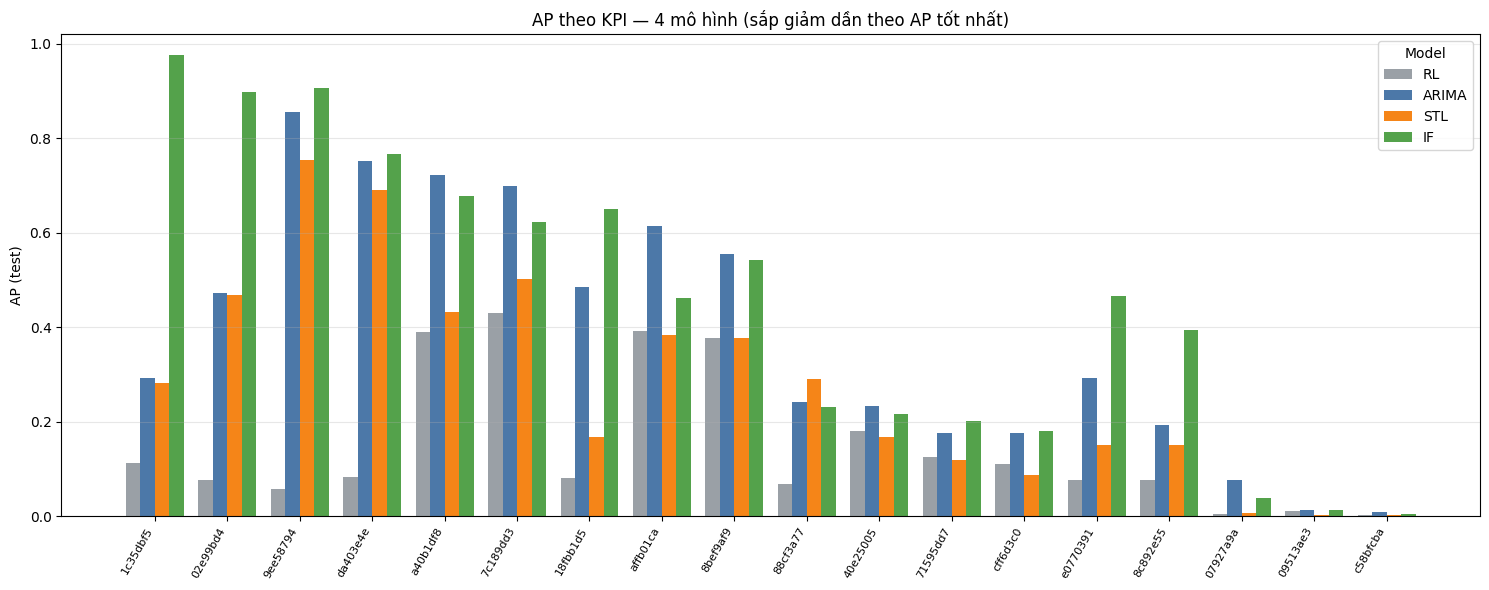

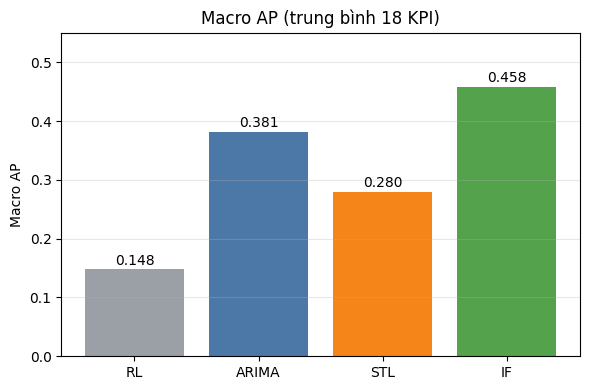

In [10]:
colors = {'RL': '#9aa0a6', 'ARIMA': '#4c78a8', 'STL': '#f58518', 'IF': '#54a24b'}
macro_ap = {m: float(df[f'{m}_AP'].mean()) for m in MODELS}

# (1) AP theo KPI — cột nhóm
d = df.sort_values('best_AP', ascending=False)
x = np.arange(len(d)); w = 0.2
fig, ax = plt.subplots(figsize=(15, 6))
for i, m in enumerate(MODELS):
    ax.bar(x + (i - 1.5) * w, d[f'{m}_AP'].values, w, label=m, color=colors[m])
ax.set_xticks(x); ax.set_xticklabels(d['kpi'].values, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('AP (test)'); ax.set_ylim(0, 1.02)
ax.set_title('AP theo KPI — 4 mô hình (sắp giảm dần theo AP tốt nhất)')
ax.legend(title='Model'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# (2) Macro AP — 4 cột
fig, ax = plt.subplots(figsize=(6, 4))
vals = [macro_ap[m] for m in MODELS]
ax.bar(MODELS, vals, color=[colors[m] for m in MODELS])
for i, v in enumerate(vals):
    ax.text(i, v + 0.008, f'{v:.3f}', ha='center', fontsize=10)
ax.set_ylabel('Macro AP'); ax.set_ylim(0, max(vals) * 1.2)
ax.set_title('Macro AP (trung bình 18 KPI)'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()